In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv("../data/heart_disease_data.csv")

606


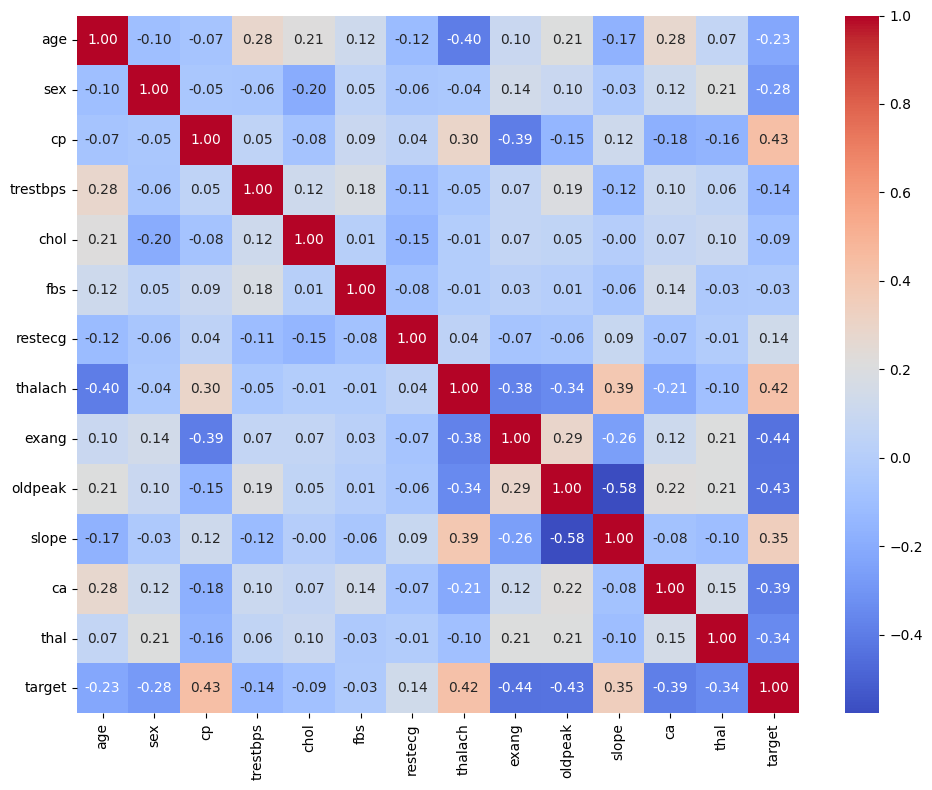

In [7]:
# Correlation Matrix (Pearson Correlation)
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.tight_layout()
plt.show()

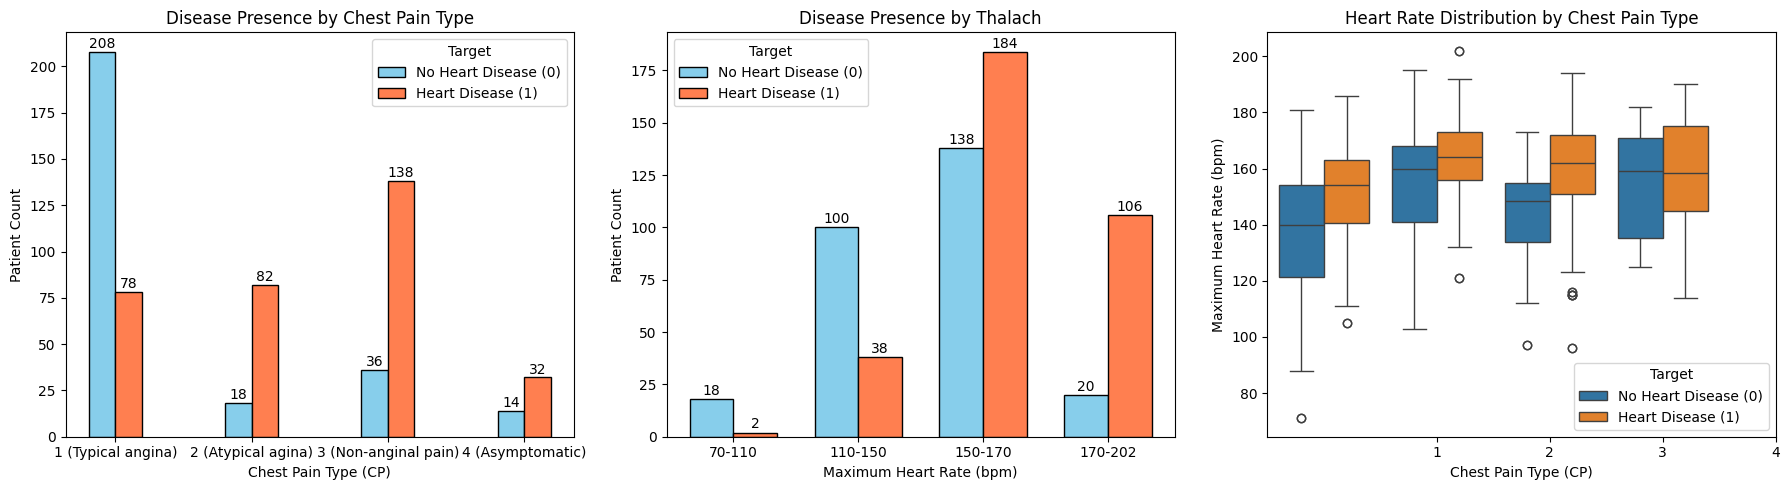

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. CP vs TARGET: GROUPED BAR CHART
cp_counts = pd.crosstab(df['cp'], df['target'])
x = np.arange(len(cp_counts.index))  * 1.8
width = 0.35

axes[0].bar(x - width/2, cp_counts[0], width, label='No Heart Disease (0)', color='skyblue', edgecolor='black')
axes[0].bar(x + width/2, cp_counts[1], width, label='Heart Disease (1)', color='coral', edgecolor='black')

for i, (idx, row) in enumerate(cp_counts.iterrows()):
    axes[0].text(i * 1.8 - width/2, row[0] + 0.5, f'{int(row[0])}', ha='center', va='bottom')
    axes[0].text(i * 1.8 + width/2, row[1] + 0.5, f'{int(row[1])}', ha='center', va='bottom')

axes[0].set_title('Disease Presence by Chest Pain Type')
axes[0].set_xlabel('Chest Pain Type (CP)')
axes[0].set_ylabel('Patient Count')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['1 (Typical angina)', '2 (Atypical agina)', '3 (Non-anginal pain)', '4 (Asymptomatic)'])
axes[0].legend(title='Target')

# 2. THALACH vs TARGET: GROUPED BAR CHART
df['thalach_bin'] = pd.cut(df['thalach'], bins=4, labels=['70-110', '110-150', '150-170', '170-202'])

thalach_counts = pd.crosstab(df['thalach_bin'], df['target'])
x_thalach = np.arange(len(thalach_counts.index))

axes[1].bar(x_thalach - width/2, thalach_counts[0], width, label='No Heart Disease (0)', color='skyblue', edgecolor='black')
axes[1].bar(x_thalach + width/2, thalach_counts[1], width, label='Heart Disease (1)', color='coral', edgecolor='black')

for i, (idx, row) in enumerate(thalach_counts.iterrows()):
    axes[1].text(i - width/2, row[0] + 0.5, f'{int(row[0])}', ha='center', va='bottom')
    axes[1].text(i + width/2, row[1] + 0.5, f'{int(row[1])}', ha='center', va='bottom')

axes[1].set_title('Disease Presence by Thalach')
axes[1].set_xlabel('Maximum Heart Rate (bpm)')
axes[1].set_ylabel('Patient Count')
axes[1].set_xticks(x_thalach)
axes[1].set_xticklabels(['70-110', '110-150', '150-170', '170-202'], rotation=0)
axes[1].legend(title='Target')

# 3. THALACH vs CP: Boxplot
sns.boxplot(data=df, x='cp', y='thalach', hue='target', ax=axes[2])
axes[2].set_title('Heart Rate Distribution by Chest Pain Type')
axes[2].set_xlabel('Chest Pain Type (CP)')
axes[2].set_ylabel('Maximum Heart Rate (bpm)')
axes[2].set_xticks(range(1, 5))
axes[2].set_xticklabels(['1', '2', '3', '4'])
handles, labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles, ['No Heart Disease (0)', 'Heart Disease (1)'], title='Target')

plt.tight_layout()
plt.show()